In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# Preprocessing Pipeline

# Data Cleaning 

In [7]:
df["Income"]=df["Income"].fillna(df["Income"].median())

In [8]:
df.isnull().sum()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engg

In [9]:
#converting
df["age"]=2026-df["Year_Birth"]

In [10]:
'''to derive the customer_tenure days ,we need to count the days from a particular reference date,
but intially we need to convert that values to type-datetime ,because they may look like dates to us
but are actually strings ,and we need to be converted to datetime'''

df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst=True)
reference_date=df["Dt_Customer"].max()
df["Customer_Tenure_Days"]=(reference_date-df["Dt_Customer"]).dt.days

'''pandas accepts datetime in format month-day-year,but in our data date is first,
so we mention it saying dayfirst=True'''

'pandas accepts datetime in format month-day-year,but in our data date is first,\nso we mention it saying dayfirst=True'

In [11]:
#combining
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'age', 'Customer_Tenure_Days'],
      dtype='str')

In [12]:
df["Spending"]=df['MntWines']+df['MntFruits']+df['MntMeatProducts']+ df['MntFishProducts']+ df['MntSweetProducts']+df['MntGoldProds']

In [13]:
df["Total_Children"]=df['Teenhome']+df['Kidhome']

In [14]:
#Transform
df["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [15]:
df["Education"]=df["Education"].replace(
    {"Graduation":"Graduate",
     "PhD":"Post_Graduate","Master":"Post_Graduate",
     "2n Cycle":"Under_Graduate","Basic":"Under_Graduate"})

In [16]:
df['Marital_Status'].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [17]:
df["Living_with"]=df["Marital_Status"].replace({
    "Married":"Together",
    "Single":"Alone","Divorced":"Alone","Widow":"Alone","Absurd":"Alone","YOLO":"Alone"})

In [18]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Spending,Total_Children,Living_with
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Together
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Together
4,5324,1981,Post_Graduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Together


# Drop Columns

In [19]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'age', 'Customer_Tenure_Days', 'Spending',
       'Total_Children', 'Living_with'],
      dtype='str')

In [20]:
cols=["ID","Marital_Status","Year_Birth","Kidhome","Teenhome","Dt_Customer",'MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']
df_cleaned=df.drop(columns=df[cols])

In [21]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Spending,Total_Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Together
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Together
4,Post_Graduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Together


In [22]:
df_cleaned.shape

(2240, 15)

# Remove Outliers

In [23]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'age',
       'Customer_Tenure_Days', 'Spending', 'Total_Children', 'Living_with'],
      dtype='str')

In [24]:
#we dont touch the numof purchases columns they effect the final outcome
cols=["Income","age","Total_Children","Spending","Customer_Tenure_Days","NumCatalogPurchases"]

<Figure size 800x600 with 0 Axes>

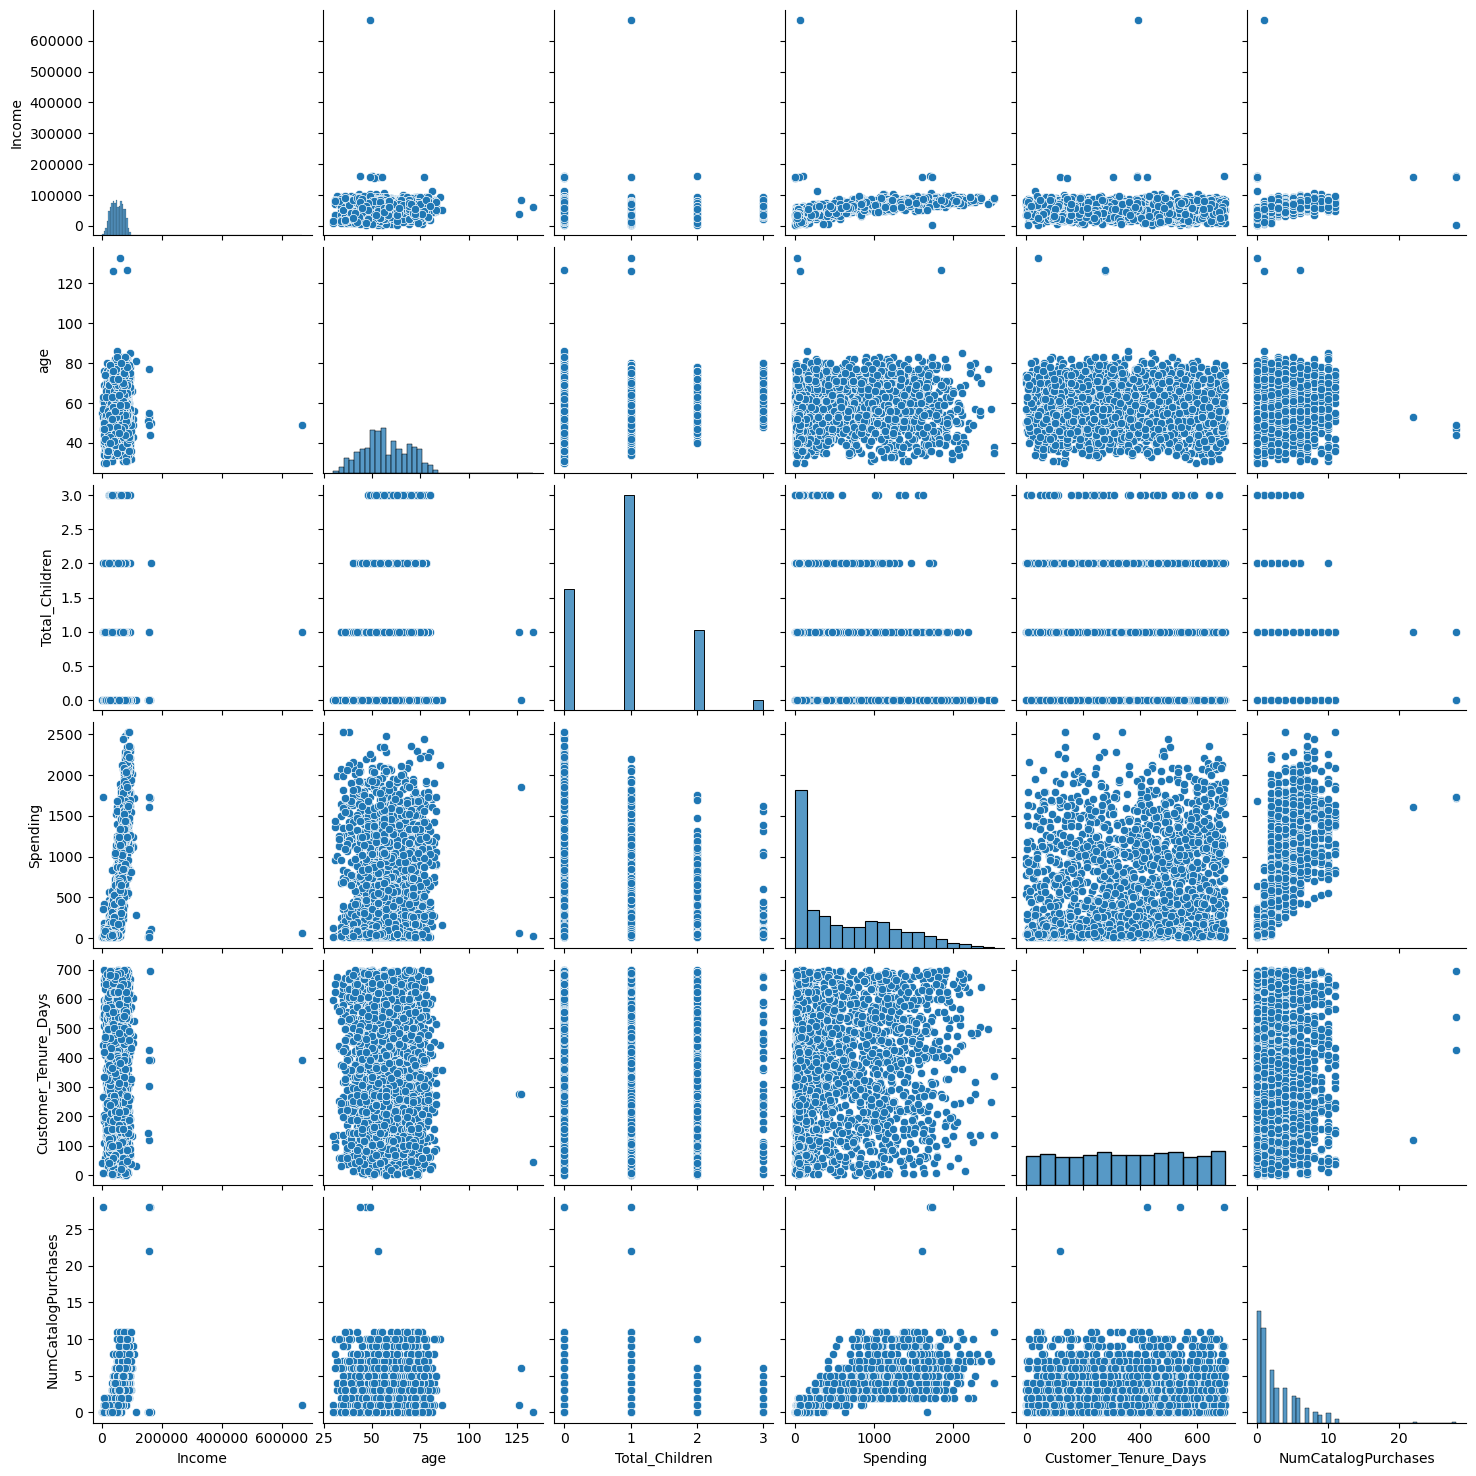

In [25]:
#pairplot -to identify outliers
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,6))
sns.pairplot(df_cleaned[cols])

In [26]:
df_cleaned=df_cleaned[ (df_cleaned["Income"]<600_000) ]
df_cleaned=df_cleaned[ (df_cleaned["age"]<90) ]

In [27]:
#Encoding
from sklearn.preprocessing import OneHotEncoder

In [28]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'age',
       'Customer_Tenure_Days', 'Spending', 'Total_Children', 'Living_with'],
      dtype='str')

In [29]:
ohe=OneHotEncoder()
cols=["Education","Living_with"]
encoded=ohe.fit_transform(df_cleaned[cols]).toarray()
#it returns data in the form on matrix ,which should be converted into dataframe

In [30]:
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df_cleaned.index)

In [31]:
df_encoded=pd.concat([df_cleaned.drop(columns=cols),encoded_df],axis=1)

In [32]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Spending,Total_Children,Education_Graduate,Education_Post_Graduate,Education_Under_Graduate,Living_with_Alone,Living_with_Together
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [33]:
df_encoded.shape

(2236, 18)

In [34]:
#Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [35]:
X=df_encoded
X_scaled=scaler.fit_transform(X)

In [36]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]])

# Visualisation

In [37]:
#PCA
from sklearn.decomposition import PCA

In [38]:
#2D
pca=PCA(n_components=2)
X_pca2=pca.fit_transform(X_scaled)

In [39]:
X_pca2

array([[ 2.7087298 ,  2.39869224],
       [-1.76655338,  1.82575242],
       [ 1.81995208, -1.07430148],
       ...,
       [ 1.42793889,  1.81716429],
       [ 1.90073104, -1.4254157 ],
       [-0.96995283, -0.67250249]])

<Axes: >

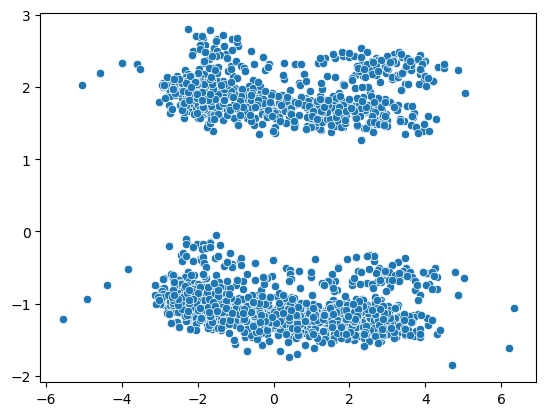

In [40]:
sns.scatterplot(x=X_pca2[:,0],y=X_pca2[:,1])

In [41]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

In [42]:
#3D
pca=PCA(n_components=3)
X_pca3=pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3d projection')

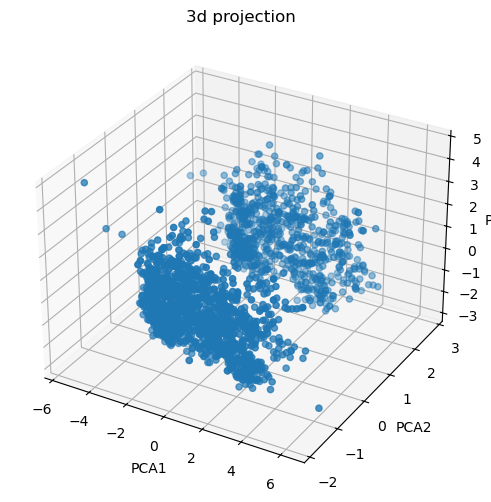

In [43]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca3[:,0],X_pca3[:,1],X_pca3[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Finding k

In [44]:
#Elbow method
#this is a smartcart clustering project so we aim clustering in few groups max 6,so we choose k in range 1,10
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,11):
    model=KMeans(n_clusters=k,random_state=42)
    labels=model.fit_predict(X_pca3)
    wcss.append(model.inertia_)

<Axes: >

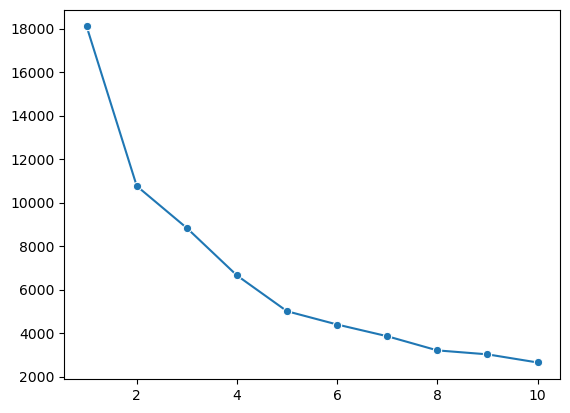

In [45]:
#plotting
sns.lineplot(x=range(1,11),y=wcss,marker="o")

In [46]:
from kneed import KneeLocator

In [47]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

In [48]:
optimal_k=knee.elbow
print("optimal_k:",optimal_k)

optimal_k: 4


In [54]:
#Silhouette score
from sklearn.metrics import silhouette_score
SS=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca3)
    score=silhouette_score(X_pca3,labels)
    SS.append(score)

<Axes: >

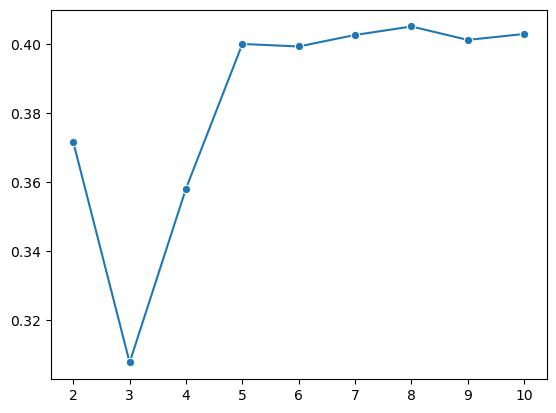

In [56]:
sns.lineplot(x=range(2,11),y=SS,marker="o")

Text(0, 0.5, 'SS')

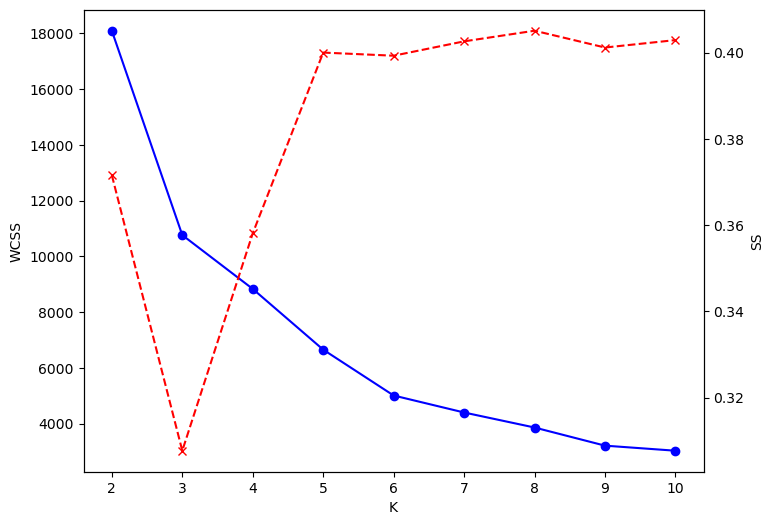

In [57]:
k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, wcss[:len(k_range)], marker="o", color="blue") 
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, SS[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

# Clustering

In [59]:
#kmeans
kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca3)

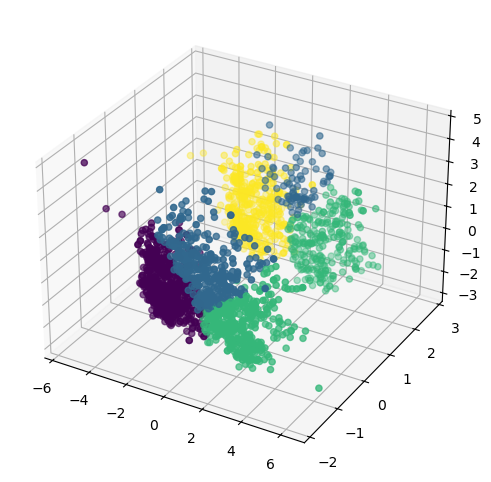

In [63]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=labels_kmeans)

In [66]:
#Agglomerative
from sklearn.cluster import AgglomerativeClustering
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca3)

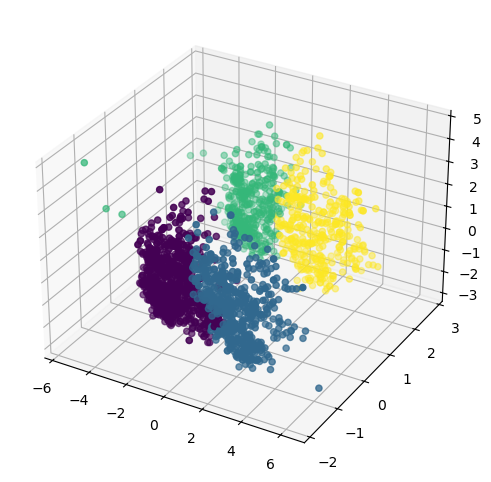

In [68]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca3[:, 0], X_pca3[:, 1], X_pca3[:, 2], c=labels_agg)

In [ ]:
#Agglomerative clustering separated well


In [69]:
# Characterization of Clusters
X["cluster"] = labels_agg

In [70]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Customer_Tenure_Days,Spending,Total_Children,Education_Graduate,Education_Post_Graduate,Education_Under_Graduate,Living_with_Alone,Living_with_Together,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0,0


<Axes: xlabel='cluster', ylabel='count'>

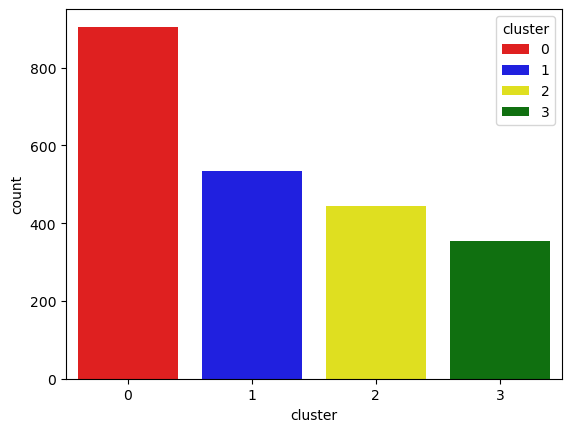

In [71]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Spending', ylabel='Income'>

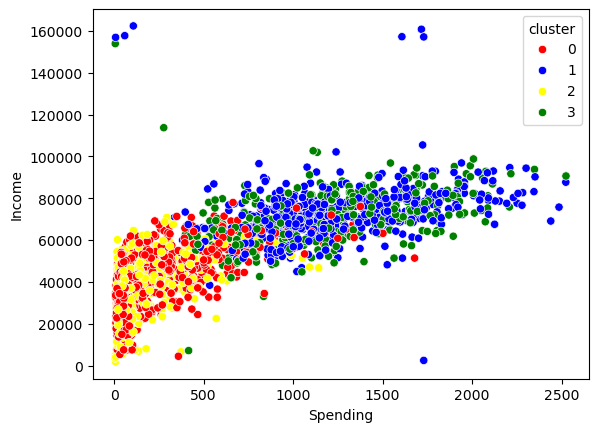

In [74]:
#Income vs spending
sns.scatterplot(x=X["Spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [72]:
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        age  Customer_Tenure_Days     Spending  \
cluster            